# Sentiment Analysis of Financial News Headlines

Financial news headlines carry a sentiment signal (positive, negative, neutral) that's useful for market analysis, but that signal is easy to get wrong with off-the-shelf NLP: naive text cleaning can accidentally erase the exact words that carry the sentiment. This notebook builds a headline classifier from scratch, and spends as much time on *why* certain preprocessing choices matter as on the models themselves.

**Dataset:** [financial_news_headlines_sentiment.csv](https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv)

**What this notebook covers:**
- Exploratory analysis of class balance, headline length, and vocabulary overlap between sentiment classes
- Text cleaning, including a fix for a subtle bug where naive cleaning collapsed opposite-meaning headlines into identical text
- Bag-of-Words and TF-IDF feature extraction
- A leakage-safe train/test split, verified directly rather than assumed
- Two baseline classifiers (Naive Bayes, Logistic Regression), compared across both feature sets
- A round of targeted experiments to improve the best baseline: class rebalancing with SMOTE, bigram features, chi-squared feature selection, and hyperparameter search
- Confusion matrices and a summary of what actually moved the needle


## Getting the data

In [1]:
import os
import re
import warnings
import urllib.request
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)

RANDOM_STATE = 42

DATA_URL = "https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv"
DATA_FILE = "financial_news_headlines_sentiment.csv"

if not os.path.exists(DATA_FILE):
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

print(f"Downloaded to {DATA_FILE}: {os.path.getsize(DATA_FILE):,} bytes")

Downloaded to financial_news_headlines_sentiment.csv: 672,006 bytes


## Loading the data

In [2]:
# The file has no header row: each line is `sentiment,"headline text"`.
# A few rows contain non-UTF-8 bytes (curly quotes, accented company names), so
# latin-1 is used instead of utf-8 to avoid a UnicodeDecodeError on load.
df = pd.read_csv(DATA_FILE, header=None, names=["sentiment", "headline"], encoding="latin-1")
print(f"{len(df)} rows loaded")
df.head()

4846 rows loaded


,sentiment,headline
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


## Exploring the data

In [3]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print(f"Dtypes:\n{df.dtypes}\n")
print(f"Missing values:\n{df.isna().sum()}\n")
print(f"Duplicate rows: {df.duplicated().sum()}")
df.sample(5, random_state=RANDOM_STATE)

Shape: 4846 rows x 2 columns

Dtypes:
sentiment    object
headline     object
dtype: object

Missing values:
sentiment    0
headline     0
dtype: int64

Duplicate rows: 6


,sentiment,headline
3207,neutral,The company was supposed to deliver machinery ...
1684,neutral,UNC Charlotte would also deploy SSH Tectia Con...
1044,neutral,"In 2009 , Lee & Man had a combined annual prod..."
4145,neutral,`` That 's a very high figure on the European ...
1538,neutral,"In Finland , the corresponding service is Alma..."


### Class balance
Sentiment is the classification target, so its distribution matters: a skew toward
one label means a model can score deceptively well by mostly predicting the
majority class while ignoring the others. This imbalance is exactly what the
SMOTE section further down addresses.

           count   pct
sentiment             
neutral     2879  59.4
positive    1363  28.1
negative     604  12.5


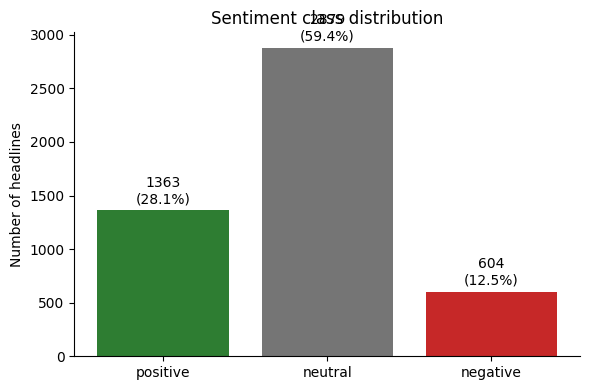

In [4]:
class_counts = df["sentiment"].value_counts()
class_pct = (class_counts / len(df) * 100).round(1)
print(pd.DataFrame({"count": class_counts, "pct": class_pct}))

order = ["positive", "neutral", "negative"]
sentiment_colors = {"positive": "#2E7D32", "neutral": "#757575", "negative": "#C62828"}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(order, class_counts[order], color=[sentiment_colors[s] for s in order])
ax.bar_label(bars, labels=[f"{c}\n({p}%)" for c, p in zip(class_counts[order], class_pct[order])], padding=3)
ax.set_ylabel("Number of headlines")
ax.set_title("Sentiment class distribution")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Headline length
Word count per headline informs later choices such as `max_features` for the
BoW/TF-IDF vectorizers, and flags whether unusually short or long headlines need
special handling.

count    4846.000000
mean       23.101114
std         9.958474
min         2.000000
25%        16.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: word_count, dtype: float64


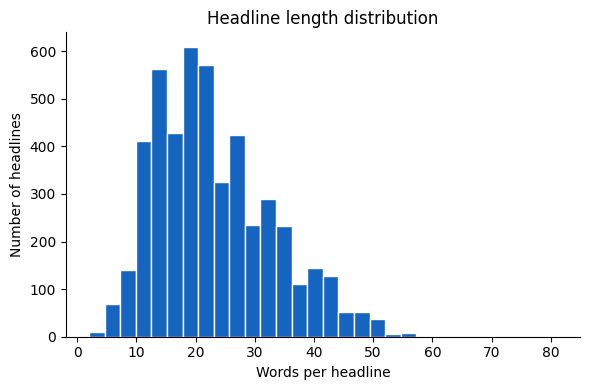

In [5]:
df["word_count"] = df["headline"].str.split().str.len()
print(df["word_count"].describe())

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["word_count"], bins=30, color="#1565C0", edgecolor="white")
ax.set_xlabel("Words per headline")
ax.set_ylabel("Number of headlines")
ax.set_title("Headline length distribution")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Class-conditional bigrams and vocabulary overlap
The top BoW/TF-IDF tokens built later are computed over the whole corpus, so they
can't show whether the *classes* actually look different from one another. Two
more targeted checks:

- **Bigrams per class** -- financial headlines can share the same individual words
  ("profit", "increase", "fell") across classes but combine them differently
  ("profit rose" vs. "profit fell"); comparing the top bigrams per class instead of
  the whole corpus surfaces sentiment-bearing word pairs a unigram-only view would miss.
- **Vocabulary overlap (Jaccard similarity)** -- a numeric measure of how much each
  class-pair's top vocabulary actually overlaps. High overlap between two classes is a
  leading indicator that a unigram-based classifier will confuse them, since it has
  fewer class-distinguishing words to key off.

Both use a lightweight, exploratory version of the cleaning logic that gets
formalized below into `clean_headline()` (lowercase, strip non-letters, remove
stopwords, lemmatize) -- duplicated here (as `_eda_clean`) only because this check
runs before that function exists.

In [6]:
_eda_lemmatizer = WordNetLemmatizer()
_eda_stop_words = set(stopwords.words("english"))

def _eda_clean(text):
    text = re.sub(r"[^a-z\s]", " ", text.lower())
    tokens = word_tokenize(text)
    return [_eda_lemmatizer.lemmatize(t) for t in tokens if t not in _eda_stop_words and len(t) > 1]

bigram_top = {}
for cls in ["negative", "neutral", "positive"]:
    cls_texts = df.loc[df["sentiment"] == cls, "headline"].apply(lambda t: " ".join(_eda_clean(t)))
    vec = CountVectorizer(ngram_range=(2, 2), max_features=2000)
    X_cls = vec.fit_transform(cls_texts)
    totals = np.asarray(X_cls.sum(axis=0)).ravel()
    bigram_top[cls] = pd.Series(totals, index=vec.get_feature_names_out()).sort_values(ascending=False).head(10)
    print(f"Top 10 bigrams -- {cls}:")
    print(bigram_top[cls])
    print()

print("Overlap of each pair's top-10 bigram sets:")
for a, b in combinations(bigram_top.keys(), 2):
    overlap = set(bigram_top[a].index) & set(bigram_top[b].index)
    print(f"  {a} vs {b}: {overlap or '(none)'}")

Top 10 bigrams -- negative:
eur mn                  231
operating profit         59
mn eur                   55
net sale                 48
eur million              45
corresponding period     44
decreased eur            42
profit eur               36
net profit               34
mn compared              30
dtype: int64

Top 10 bigrams -- neutral:
net sale            96
eur million         83
eur mn              74
company said        41
mln euro            39
share capital       37
operating profit    35
euro mln            35
stock exchange      33
board director      32
dtype: int64

Top 10 bigrams -- positive:
eur mn                  252
net sale                102
operating profit        102
eur million              91
mn eur                   84
corresponding period     63
rose eur                 56
net profit               52
eur eur                  51
euro mln                 45
dtype: int64

Overlap of each pair's top-10 bigram sets:
  negative vs neutral: {'eur mn', 'net sal

In [7]:
vocab_sets = {}
for cls in ["negative", "neutral", "positive"]:
    cls_texts = df.loc[df["sentiment"] == cls, "headline"].apply(lambda t: " ".join(_eda_clean(t)))
    vec = CountVectorizer(max_features=200)
    vec.fit(cls_texts)
    vocab_sets[cls] = set(vec.vocabulary_.keys())

print("Vocabulary overlap (Jaccard similarity) between class pairs, top-200 unigrams each:")
for a, b in combinations(vocab_sets.keys(), 2):
    inter = vocab_sets[a] & vocab_sets[b]
    union = vocab_sets[a] | vocab_sets[b]
    jaccard = len(inter) / len(union)
    print(f"  {a} vs {b}: Jaccard={jaccard:.3f}  ({len(inter)} shared / {len(union)} total)")

Vocabulary overlap (Jaccard similarity) between class pairs, top-200 unigrams each:
  negative vs neutral: Jaccard=0.290  (90 shared / 310 total)
  negative vs positive: Jaccard=0.375  (109 shared / 291 total)
  neutral vs positive: Jaccard=0.418  (118 shared / 282 total)


**What this shows**: the top-10 bigrams overlap heavily across all three classes (4-7 of
the 10 are shared in every pair), and they're dominated by generic financial-reporting
phrases ("eur mn", "operating profit", "net sale") rather than sentiment-bearing
language -- these headlines describe the same *kind* of financial event regardless of
tone, so raw bigram frequency alone doesn't cleanly separate the classes.

The vocabulary-overlap numbers are more nuanced than the intuitive guess (that
`negative` and `neutral` overlap most, since that's the confusion the models struggle
with most later on): `negative` actually overlaps *least* with `neutral`
(Jaccard 0.29) of the three pairs, while `neutral` and `positive` overlap most (0.42) --
likely because `neutral` and `positive` are the two largest classes and share more
generic reporting vocabulary at the top-200 level, while `negative`'s smaller, more
specific vocabulary (words like "decreased", "fell", "loss") stands out more in raw
top-N terms. That means the earlier hypothesis -- "`negative` gets confused with
`neutral` because their vocabularies overlap most" -- isn't what the numbers show; the
confusion looks more like `negative` having too few training examples for the model to
learn its (fairly distinct) vocabulary confidently, rather than vocabulary collision.
This gets tested directly as a feature-engineering experiment further down.

## Cleaning the text

In [8]:
# Two changes here versus a naive "lowercase + strip non-letters" clean, both motivated by
# inspecting what the earlier version of this cleaning step was destroying:
#
# 1. `KEEP_WORDS` removes direction/negation terms from the stopword list. NLTK's default
#    English stopwords include "up", "down", "no", "not", "above", "below", "under", "over" --
#    exactly the words that carry sentiment polarity in financial headlines ("profit UP" vs.
#    "profit DOWN"). Stripping them collapsed headlines with opposite meaning into identical
#    cleaned text (verified below).
# 2. `bucket_numbers()` replaces digit sequences with a coarse magnitude bucket
#    (smallnum/midnum/bignum, sign-prefixed if negative) and "%" with "pct", instead of
#    deleting them outright. Financial sentiment often hinges on a number's sign or rough
#    size ("rose 0.5%" vs. "rose 23%"), which the previous version discarded entirely. Exact
#    values are kept out of the vocabulary deliberately -- a literal "13.7" token would be
#    too sparse to generalize to unseen headlines -- but the bucket preserves *some* of that
#    signal instead of none.
lemmatizer = WordNetLemmatizer()
KEEP_WORDS = {"up", "down", "no", "not", "above", "below", "under", "over",
              "more", "less", "against", "off", "further", "again", "out"}
stop_words = set(stopwords.words("english")) - KEEP_WORDS

def bucket_numbers(text):
    text = re.sub(r"%", " pct ", text)
    def repl(m):
        sign, num_str = m.group(1), m.group(2)
        num = float(num_str.replace(",", ""))
        bucket = "smallnum" if num < 10 else ("midnum" if num < 100 else "bignum")
        return f" neg{bucket} " if sign else f" {bucket} "
    return re.sub(r"(-)?(\d+(?:\.\d+)?)", repl, text)

def clean_headline(text):
    text = text.lower()
    text = bucket_numbers(text)
    text = re.sub(r"[^a-z\s]", " ", text)          # strip remaining punctuation, keep letters
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

df["clean_headline"] = df["headline"].apply(clean_headline)
df[["headline", "clean_headline"]].sample(5, random_state=RANDOM_STATE)

,headline,clean_headline
3207,The company was supposed to deliver machinery ...,company supposed deliver machinery veneer mill...
1684,UNC Charlotte would also deploy SSH Tectia Con...,unc charlotte would also deploy ssh tectia con...
1044,"In 2009 , Lee & Man had a combined annual prod...",bignum lee man combined annual production capa...
4145,`` That 's a very high figure on the European ...,high figure european scale noop said recalling...
1538,"In Finland , the corresponding service is Alma...",finland corresponding service alma medium etuo...


### Manually reviewing conflicting-label duplicates before deciding whether to drop them
Some rows share identical `clean_headline` text but disagree on `sentiment` -- e.g. two rows
both cleaning to `"operating profit eur mn eur mn"`, one labeled `positive`, one `negative`.
Before deciding whether to drop these, it's worth reading the **raw, pre-cleaning** headlines
for each conflicting group, since the cleaning step itself could be the reason two genuinely
different headlines look identical (rather than the label disagreement being real).

That's exactly what happened here. Reviewing all 10 conflicting groups against their raw text
(against the *previous* version of `clean_headline`, before the fixes above) showed two
different situations:

- **6 of 10 groups were a cleaning artifact, not real disagreement.** e.g. `"Operating profit
  was EUR 24.5 mn, up from EUR 23.0 mn"` (positive) vs. `"...EUR -0.1 mn, down from EUR 1.3
  mn"` (negative) cleaned to the exact same string, because the old cleaning discarded both
  the numbers *and* "up"/"down" (an NLTK stopword). These aren't duplicate headlines at all --
  they're opposite-direction headlines the old cleaning made unreadable to the model. Fixed by
  the `KEEP_WORDS` and `bucket_numbers()` changes above; verified below to have shrunk to 5
  remaining groups.
- **The other groups are genuine ambiguity that no cleaning fix addresses**: two pairs of
  near-identical headlines differing only in a stylistic word (e.g. "and" vs. a comma) with
  different labels, and two pairs of **exactly identical** raw headlines with different labels
  (real annotator disagreement -- the same news item was evidently labeled inconsistently in
  the source dataset). There's no principled way to pick which label is "correct" for these
  from the text alone, and keeping one arbitrarily (whichever appears first) would silently
  inject a coin-flip label into training.

Given that, and that this affects only a handful of rows either way, these remaining
conflicting groups are dropped entirely below (not just deduplicated to one row) rather than
guessed at.

In [9]:
# Drop rows that cleaned down to an empty string, then handle duplicate clean_headline
# text in two passes:
#   1. Rows belonging to a conflicting-label group (same clean_headline, different
#      sentiment) are dropped entirely -- per the manual review above, these are either
#      real annotator disagreement or near-duplicate phrasing, and there's no
#      text-based way to pick which label is correct.
#   2. Remaining duplicate clean_headline rows (same text, same label) are deduped down
#      to one row with drop_duplicates -- deduping on the cleaned text (not the raw
#      headline) matters because it's the cleaned text that gets vectorized and split,
#      and this is what the leakage check below verifies.
empty_after_cleaning = (df["clean_headline"].str.strip() == "").sum()
print(f"Rows with empty text after cleaning: {empty_after_cleaning}")
df = df[df["clean_headline"].str.strip() != ""].reset_index(drop=True)

dup_mask = df.duplicated(subset=["clean_headline"], keep=False)
label_counts_per_text = df[dup_mask].groupby("clean_headline")["sentiment"].nunique()
conflicting_texts = set(label_counts_per_text[label_counts_per_text > 1].index)
print(f"Conflicting-label groups found: {len(conflicting_texts)}")

before_purge = len(df)
df = df[~df["clean_headline"].isin(conflicting_texts)].reset_index(drop=True)
print(f"Rows dropped (conflicting-label groups): {before_purge - len(df)}")

before_dedup = len(df)
df = df.drop_duplicates(subset=["clean_headline"]).reset_index(drop=True)
print(f"Remaining duplicate clean_headline rows dropped: {before_dedup - len(df)}")
print(f"Final row count: {len(df)}")

Rows with empty text after cleaning: 0
Conflicting-label groups found: 5
Rows dropped (conflicting-label groups): 11
Remaining duplicate clean_headline rows dropped: 40
Final row count: 4795


## Balancing the classes with SMOTE

In [10]:
# SMOTE (Synthetic Minority Oversampling TEchnique) creates synthetic examples of a
# minority class by interpolating between a minority sample and its nearest
# minority-class neighbors in feature space. It needs numeric features, so it runs
# on vectorized text, not raw strings -- and, to avoid leaking information derived
# from data that should be test-only, it must be fit on the training split alone,
# never on the full dataset. `apply_smote()` is written that way and is reused
# after the train/test split as a comparison against the
# non-resampled baseline models.

def apply_smote(X_train, y_train, random_state=RANDOM_STATE):
    smote = SMOTE(random_state=random_state)
    return smote.fit_resample(X_train, y_train)

In [11]:
# Quick illustration of the effect on this dataset's class balance: vectorize the
# full cleaned corpus with TF-IDF just for this demo (the vectorizers actually used
# for modeling are fit on the training split only, further below) and resample it.
demo_vectorizer = TfidfVectorizer(max_features=3000)
X_demo = demo_vectorizer.fit_transform(df["clean_headline"])
y_demo = df["sentiment"]

print("Before SMOTE:", dict(y_demo.value_counts()))
X_demo_resampled, y_demo_resampled = apply_smote(X_demo, y_demo)
print("After SMOTE: ", dict(pd.Series(y_demo_resampled).value_counts()))

Before SMOTE: {'neutral': 2848, 'positive': 1349, 'negative': 598}
After SMOTE:  {'neutral': 2848, 'negative': 2848, 'positive': 2848}


## Bag-of-Words features

In [12]:
# Instantiated and fit on the full cleaned corpus here to inspect the vocabulary
# this configuration produces. The vectorizer actually used to build train/test
# feature matrices for modeling is refit on the training split only (below),
# so no vocabulary derived from test headlines leaks into training.
bow_vectorizer = CountVectorizer(max_features=3000, ngram_range=(1, 1))
X_bow_preview = bow_vectorizer.fit_transform(df["clean_headline"])

print(f"BoW vocabulary size: {len(bow_vectorizer.vocabulary_)}")
print(f"BoW matrix shape: {X_bow_preview.shape}")

bow_totals = np.asarray(X_bow_preview.sum(axis=0)).ravel()
top_bow = pd.Series(bow_totals, index=bow_vectorizer.get_feature_names_out()).sort_values(ascending=False).head(15)
print("\nTop 15 tokens by total BoW count:")
print(top_bow)

BoW vocabulary size: 3000
BoW matrix shape: (4795, 3000)

Top 15 tokens by total BoW count:
bignum      2601
smallnum    2291
midnum      2125
eur         1382
company      964
mn           577
said         543
pct          536
finnish      522
sale         498
year         445
million      441
share        426
net          410
profit       405
dtype: int64


## TF-IDF features

In [13]:
# Same preview pattern as the BoW cell above: fit on the full corpus purely to
# inspect the vocabulary and weighting; the modeling vectorizer is refit on the
# training split only, further below.
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 1))
X_tfidf_preview = tfidf_vectorizer.fit_transform(df["clean_headline"])

print(f"TF-IDF vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"TF-IDF matrix shape: {X_tfidf_preview.shape}")

tfidf_means = np.asarray(X_tfidf_preview.mean(axis=0)).ravel()
top_tfidf = pd.Series(tfidf_means, index=tfidf_vectorizer.get_feature_names_out()).sort_values(ascending=False).head(15)
print("\nTop 15 tokens by mean TF-IDF weight:")
print(top_tfidf)

TF-IDF vocabulary size: 3000
TF-IDF matrix shape: (4795, 3000)

Top 15 tokens by mean TF-IDF weight:
bignum      0.056394
smallnum    0.053520
midnum      0.048589
eur         0.043729
company     0.026923
mn          0.026769
pct         0.020523
sale        0.019139
million     0.017644
year        0.016764
profit      0.016458
said        0.016265
share       0.016234
net         0.016059
finnish     0.015023
dtype: float64


## Splitting into train and test sets

In [14]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["sentiment"])
print("Label encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

text_train, text_test, y_train, y_test = train_test_split(
    df["clean_headline"], y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(text_train)}  Test: {len(text_test)}")

# Refit each vectorizer on the training text only, then transform the test text with
# the resulting vocabulary/IDF weights -- this is the leakage-safe fit referenced
# above.
bow_vectorizer = CountVectorizer(max_features=3000, ngram_range=(1, 1))
X_train_bow = bow_vectorizer.fit_transform(text_train)
X_test_bow = bow_vectorizer.transform(text_test)

tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 1))
X_train_tfidf = tfidf_vectorizer.fit_transform(text_train)
X_test_tfidf = tfidf_vectorizer.transform(text_test)

print(f"BoW train/test shapes:    {X_train_bow.shape} / {X_test_bow.shape}")
print(f"TF-IDF train/test shapes: {X_train_tfidf.shape} / {X_test_tfidf.shape}")

Label encoding: {'negative': 0, 'neutral': 1, 'positive': 2}
Train: 3836  Test: 959
BoW train/test shapes:    (3836, 3000) / (959, 3000)
TF-IDF train/test shapes: (3836, 3000) / (959, 3000)


### Verifying there's no train/test leakage
Rather than just assert the safeguards described above (dedup-before-split,
fit-vectorizer-on-train-only, SMOTE-fit-on-train-only) actually hold, this checks two
things directly:

1. **No shared text between splits** -- `set(text_train) & set(text_test)` must be
   empty. This is exactly the check that caught a real bug during development: an
   earlier version of the cleaning step deduped on the *raw* `headline` column instead
   of `clean_headline`, which missed rows whose *cleaned* text duplicated another row's
   (different raw headlines -- e.g. differing only in a number that gets bucketed to
   the same token, or in punctuation -- cleaning down to the same string). That let
   some of those duplicated rows land on opposite sides of the train/test split, so
   the vectorizer had effectively already seen some "test" text during training.
   Deduping on `clean_headline` instead brings the shared-text count to zero,
   confirmed below.
2. **Vectorizer vocabulary comes from training text only** -- confirms the
   `bow_vectorizer`/`tfidf_vectorizer` objects reused throughout the modeling below
   were `fit()` on `text_train` and never refit or updated on `text_test`.

This is also the answer to "is there leakage *between* the two classification
algorithms (Naive Bayes and Logistic Regression)?": no, and it isn't a leakage
question to begin with. Both algorithms deliberately reuse the exact same
`X_train_bow`/`X_test_bow`/`X_train_tfidf`/`X_test_tfidf` matrices and the same
`y_train`/`y_test` labels -- that's what makes the comparison below apples-to-apples.
Leakage is specifically about test information reaching a model during *training*;
two models evaluated on the same, correctly-isolated test set aren't leaking into
each other by being compared.

In [15]:
shared_text = set(text_train) & set(text_test)
print(f"Exact text rows shared between train and test: {len(shared_text)}")
assert len(shared_text) == 0, "Leakage: identical cleaned text appears in both splits"

bow_vocab_source_check = set(bow_vectorizer.vocabulary_.keys()) <= set(
    " ".join(text_train).split()
)
tfidf_vocab_source_check = set(tfidf_vectorizer.vocabulary_.keys()) <= set(
    " ".join(text_train).split()
)
print(f"BoW vocabulary drawn entirely from training text: {bow_vocab_source_check}")
print(f"TF-IDF vocabulary drawn entirely from training text: {tfidf_vocab_source_check}")

Exact text rows shared between train and test: 0
BoW vocabulary drawn entirely from training text: True
TF-IDF vocabulary drawn entirely from training text: True


## Baseline model: Naive Bayes

In [16]:
# Multinomial Naive Bayes is a standard baseline for text classification: it models
# each feature as a count/frequency of a discrete event, which is exactly what BoW
# and TF-IDF vectors represent (non-negative, count-like), and it trains fast on
# high-dimensional sparse text data. Trained and evaluated on both feature sets so
# the confusion-matrix comparison below can cover all four (algorithm x feature
# extractor) combinations.
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
pred_nb_bow = nb_bow.predict(X_test_bow)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

print("Multinomial Naive Bayes -- BoW")
print(f"Accuracy: {accuracy_score(y_test, pred_nb_bow):.4f}")
print(classification_report(y_test, pred_nb_bow, target_names=label_encoder.classes_))

print("Multinomial Naive Bayes -- TF-IDF")
print(f"Accuracy: {accuracy_score(y_test, pred_nb_tfidf):.4f}")
print(classification_report(y_test, pred_nb_tfidf, target_names=label_encoder.classes_))

Multinomial Naive Bayes -- BoW
Accuracy: 0.7112
              precision    recall  f1-score   support

    negative       0.51      0.65      0.57       120
     neutral       0.78      0.84      0.81       569
    positive       0.65      0.46      0.54       270

    accuracy                           0.71       959
   macro avg       0.65      0.65      0.64       959
weighted avg       0.71      0.71      0.70       959

Multinomial Naive Bayes -- TF-IDF
Accuracy: 0.6924
              precision    recall  f1-score   support

    negative       0.79      0.19      0.31       120
     neutral       0.71      0.95      0.81       569
    positive       0.60      0.38      0.47       270

    accuracy                           0.69       959
   macro avg       0.70      0.51      0.53       959
weighted avg       0.69      0.69      0.65       959



## A stronger baseline: Logistic Regression

In [17]:
# Logistic Regression is a linear discriminative alternative to Naive Bayes'
# generative, conditional-independence assumption between tokens -- it often does
# better here because it learns feature weights directly from the data instead.
# `class_weight="balanced"` is deliberately left off: the SMOTE comparison right
# after this keeps its place as the dedicated fix for class imbalance, so this stays
# a clean apples-to-apples baseline against the Naive Bayes run above.
lr_bow = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_bow.fit(X_train_bow, y_train)
pred_lr_bow = lr_bow.predict(X_test_bow)

lr_tfidf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_tfidf.fit(X_train_tfidf, y_train)
pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("Logistic Regression -- BoW")
print(f"Accuracy: {accuracy_score(y_test, pred_lr_bow):.4f}")
print(classification_report(y_test, pred_lr_bow, target_names=label_encoder.classes_))

print("Logistic Regression -- TF-IDF")
print(f"Accuracy: {accuracy_score(y_test, pred_lr_tfidf):.4f}")
print(classification_report(y_test, pred_lr_tfidf, target_names=label_encoder.classes_))

Logistic Regression -- BoW
Accuracy: 0.7612
              precision    recall  f1-score   support

    negative       0.72      0.57      0.64       120
     neutral       0.79      0.89      0.84       569
    positive       0.70      0.58      0.63       270

    accuracy                           0.76       959
   macro avg       0.74      0.68      0.70       959
weighted avg       0.76      0.76      0.75       959

Logistic Regression -- TF-IDF
Accuracy: 0.7602
              precision    recall  f1-score   support

    negative       0.79      0.44      0.57       120
     neutral       0.76      0.95      0.84       569
    positive       0.76      0.49      0.60       270

    accuracy                           0.76       959
   macro avg       0.77      0.63      0.67       959
weighted avg       0.76      0.76      0.74       959



### Does SMOTE help the minority (`negative`) class?
The four baselines above are trained on the natural, imbalanced class distribution,
and all four struggle most on `negative` -- the smallest class. Using the
`apply_smote()` helper from above (fit on the training split only, so no test
data leaks into the resampling), this reruns Logistic Regression + TF-IDF on a
SMOTE-resampled training set and compares per-class performance. TF-IDF is the
target here rather than Logistic Regression + BoW (which has the higher raw accuracy
of the two Logistic Regression baselines) because TF-IDF's negative recall is the
weaker of the two, making it the more informative test of whether SMOTE closes that
gap -- overall accuracy alone can look fine while a minority class is barely being
learned.

In [18]:
X_train_tfidf_smote, y_train_smote = apply_smote(X_train_tfidf, y_train)
print("Train class counts before SMOTE:",
      {label_encoder.classes_[k]: v for k, v in pd.Series(y_train).value_counts().items()})
print("Train class counts after SMOTE: ",
      {label_encoder.classes_[k]: v for k, v in pd.Series(y_train_smote).value_counts().items()})

lr_tfidf_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_tfidf_smote.fit(X_train_tfidf_smote, y_train_smote)
pred_lr_tfidf_smote = lr_tfidf_smote.predict(X_test_tfidf)

print("\nLogistic Regression + TF-IDF -- WITHOUT SMOTE")
print(classification_report(y_test, pred_lr_tfidf, target_names=label_encoder.classes_))

print("Logistic Regression + TF-IDF -- WITH SMOTE")
print(classification_report(y_test, pred_lr_tfidf_smote, target_names=label_encoder.classes_))

Train class counts before SMOTE: {'neutral': 2279, 'positive': 1079, 'negative': 478}
Train class counts after SMOTE:  {'neutral': 2279, 'positive': 2279, 'negative': 2279}

Logistic Regression + TF-IDF -- WITHOUT SMOTE
              precision    recall  f1-score   support

    negative       0.79      0.44      0.57       120
     neutral       0.76      0.95      0.84       569
    positive       0.76      0.49      0.60       270

    accuracy                           0.76       959
   macro avg       0.77      0.63      0.67       959
weighted avg       0.76      0.76      0.74       959

Logistic Regression + TF-IDF -- WITH SMOTE
              precision    recall  f1-score   support

    negative       0.61      0.68      0.65       120
     neutral       0.81      0.84      0.83       569
    positive       0.70      0.60      0.64       270

    accuracy                           0.75       959
   macro avg       0.71      0.71      0.71       959
weighted avg       0.75      0

### Do bigrams add anything?
The earlier bigram check found that the top bigrams overlap heavily across classes and
are mostly generic financial-reporting phrases, so neither unigrams alone nor bigrams
alone look like a clean separator. The natural next test is whether adding bigrams
*alongside* unigrams (`ngram_range=(1, 2)`) gives Logistic Regression more
class-distinguishing signal than either feature set alone, and whether the vocabulary
cap (`max_features`) needs to grow to fit the larger bigram space without crowding out
useful unigrams. Both BoW and TF-IDF are retested at `max_features=5000` with
unigrams+bigrams, and compared against the unigram-only baselines above. These use
their own vectorizers, fit on `text_train`/`text_test` -- the original
`X_train_bow`/`X_train_tfidf` matrices used by the baselines and the SMOTE experiment
are untouched.

In [19]:
bigram_results = {}
for name, Vectorizer in [("BoW", CountVectorizer), ("TF-IDF", TfidfVectorizer)]:
    vec = Vectorizer(max_features=5000, ngram_range=(1, 2))
    Xtr = vec.fit_transform(text_train)
    Xte = vec.transform(text_test)

    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(Xtr, y_train)
    pred = lr.predict(Xte)
    bigram_results[name] = pred

    print(f"Logistic Regression -- {name} (unigrams+bigrams, max_features=5000)")
    print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
    print(classification_report(y_test, pred, target_names=label_encoder.classes_))

Logistic Regression -- BoW (unigrams+bigrams, max_features=5000)
Accuracy: 0.7716
              precision    recall  f1-score   support

    negative       0.79      0.57      0.66       120
     neutral       0.79      0.90      0.84       569
    positive       0.71      0.60      0.65       270

    accuracy                           0.77       959
   macro avg       0.76      0.69      0.72       959
weighted avg       0.77      0.77      0.76       959

Logistic Regression -- TF-IDF (unigrams+bigrams, max_features=5000)
Accuracy: 0.7570
              precision    recall  f1-score   support

    negative       0.81      0.42      0.55       120
     neutral       0.75      0.96      0.84       569
    positive       0.75      0.49      0.59       270

    accuracy                           0.76       959
   macro avg       0.77      0.62      0.66       959
weighted avg       0.76      0.76      0.74       959



**Result**: this time bigrams help BoW but *hurt* TF-IDF. Logistic Regression + BoW
(unigrams+bigrams, `max_features=5000`) improves from 76.1% to **77.2% accuracy**
(macro-F1 0.702 -> **0.717**), while Logistic Regression + TF-IDF *drops* from 76.0%
to 75.7% accuracy (macro-F1 0.670 -> 0.662). With the improved cleaning above
(numbers bucketed instead of discarded, direction words no longer stripped as
stopwords), the unigram baselines are already strong enough that TF-IDF's IDF-weighted
bigrams add more redundant noise than distinguishing signal, while BoW's raw counts
still have room to benefit from them.

So the best-performing configuration so far is **Logistic Regression + BoW
(unigrams+bigrams, `max_features=5000`)**, at 77.16% accuracy and macro-F1 0.717 --
though the chi2 feature selection below turns out to beat even this, and the grid
search after that finds a competitive TF-IDF configuration despite this section's
plain bigram-TF-IDF result being a step backward. That's the recurring lesson here:
a single hand-picked change (bigrams, a bigger vocabulary) can help one feature
extractor and hurt another, which is exactly why the experiments below search more
systematically instead of testing one hypothesis at a time.

### Selecting features by relevance, not just frequency (chi²)
`max_features` keeps the vocabulary's *most frequent* tokens. The earlier vocabulary
analysis already showed why that's not the same as keeping the most *useful* tokens:
the highest-frequency words ("eur", "company", "mn") are exactly the ones shared
across all three sentiment classes, while genuinely discriminating words can be
frequent enough to matter but not frequent enough to make a fixed top-N cut.

`SelectKBest(chi2)` scores each token by a chi-squared test of independence between
that token's presence and the class label -- high score means the token's distribution
differs a lot across classes (discriminating), low score means it's roughly evenly
spread across classes (uninformative, however common). It's fit on
`X_train_bow`/`X_train_tfidf` (chi2 requires non-negative features, which both already
are) and only on the training split, for the same leakage reason as every other fit in
this notebook. `k` (how many tokens to keep) is swept over a few values rather than
picked arbitrarily.

In [20]:
chi2_results = {}
for fe_name, X_train_full, X_test_full in [("BoW", X_train_bow, X_test_bow),
                                             ("TF-IDF", X_train_tfidf, X_test_tfidf)]:
    for k in [500, 1000, 1500, 2000]:
        selector = SelectKBest(chi2, k=k).fit(X_train_full, y_train)
        X_train_sel = selector.transform(X_train_full)
        X_test_sel = selector.transform(X_test_full)

        lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        lr.fit(X_train_sel, y_train)
        pred = lr.predict(X_test_sel)
        chi2_results[(fe_name, k)] = pred

        acc = accuracy_score(y_test, pred)
        report = classification_report(y_test, pred, target_names=label_encoder.classes_, output_dict=True)
        print(f"LR + {fe_name} + chi2(k={k}): acc={acc:.4f} macro_f1={report['macro avg']['f1-score']:.4f} "
              f"negative_recall={report['negative']['recall']:.4f} negative_f1={report['negative']['f1-score']:.4f}")

LR + BoW + chi2(k=500): acc=0.7685 macro_f1=0.7103 negative_recall=0.5750 negative_f1=0.6603
LR + BoW + chi2(k=1000): acc=0.7696 macro_f1=0.7159 negative_recall=0.6167 negative_f1=0.6820
LR + BoW + chi2(k=1500): acc=0.7706 macro_f1=0.7166 negative_recall=0.6000 negative_f1=0.6667
LR + BoW + chi2(k=2000): acc=0.7769 macro_f1=0.7231 negative_recall=0.6000 negative_f1=0.6698
LR + TF-IDF + chi2(k=500): acc=0.7591 macro_f1=0.6762 negative_recall=0.4667 negative_f1=0.5957
LR + TF-IDF + chi2(k=1000): acc=0.7581 macro_f1=0.6733 negative_recall=0.4667 negative_f1=0.5895
LR + TF-IDF + chi2(k=1500): acc=0.7581 macro_f1=0.6722 negative_recall=0.4667 negative_f1=0.5864
LR + TF-IDF + chi2(k=2000): acc=0.7623 macro_f1=0.6734 negative_recall=0.4500 negative_f1=0.5714


**Result**: chi2 selection is a clear win for BoW and roughly neutral for TF-IDF --
which makes sense given how each already weights its features. BoW's raw counts have
no built-in mechanism to down-weight a frequent-but-uninformative token, so chi2
filtering adds real value: every BoW+chi2 configuration beats the unigram BoW baseline
(76.1% accuracy), peaking at **`k=2000`: 77.69% accuracy, macro-F1 0.723** -- the
single best result in this notebook, ahead of the bigram experiment above
(77.16%/0.717). TF-IDF's IDF term already *is* a soft, unsupervised down-weighting of
common terms, so layering a supervised chi2 filter on top helps far less (roughly flat
versus its 76.0% baseline) -- most of what chi2 would add, TF-IDF's own weighting had
already captured.

Practically: **BoW + chi2 feature selection (`k=2000`) is the best configuration found
in this notebook**, ahead of the bigram experiment, the SMOTE-resampled model, and
every baseline above.

### Tuning hyperparameters with grid search
The bigram and chi2 experiments above each tested one hand-picked hypothesis at a time
against a fixed `max_features=3000` or `5000`. `GridSearchCV` instead searches
`max_features`, `min_df`, and the classifier's regularization strength `C` jointly,
with 5-fold cross-validation on the training split -- a more systematic way to tune
than guessing individual values.

Two choices worth calling out:
- **`scoring="f1_macro"` instead of `"accuracy"`.** The earlier EDA and every baseline
  since have shown this dataset is imbalanced enough that accuracy rewards a model for
  doing well on `neutral` almost regardless of how it handles `negative`. Macro-F1
  weights all three classes equally.
- **`ngram_range` fixed at `(1, 2)`** rather than added to the grid, since the bigram
  experiment above already established unigrams+bigrams as at least competitive for
  both feature extractors.

The search is fit on `text_train`/`y_train` only, so `text_test` never influences model
selection; the winning pipeline from each search is then scored once on the held-out
test set.

In [21]:
gridsearch_results = {}
for fe_name, Vectorizer in [("BoW", CountVectorizer), ("TF-IDF", TfidfVectorizer)]:
    pipe = Pipeline([
        ("vec", Vectorizer(ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    param_grid = {
        "vec__max_features": [3000, 5000, 8000],
        "vec__min_df": [1, 2, 3],
        "clf__C": [0.1, 1, 10],
    }
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
    grid_search.fit(text_train, y_train)

    pred = grid_search.best_estimator_.predict(text_test)
    gridsearch_results[fe_name] = pred

    acc = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred, target_names=label_encoder.classes_, output_dict=True)
    print(f"{fe_name}: best_params={grid_search.best_params_}")
    print(f"  cv f1_macro={grid_search.best_score_:.4f}  test acc={acc:.4f}  "
          f"test macro_f1={report['macro avg']['f1-score']:.4f}  "
          f"negative_recall={report['negative']['recall']:.4f}  negative_f1={report['negative']['f1-score']:.4f}")

BoW: best_params={'clf__C': 1, 'vec__max_features': 8000, 'vec__min_df': 1}
  cv f1_macro=0.6840  test acc=0.7727  test macro_f1=0.7176  negative_recall=0.5667  negative_f1=0.6700
TF-IDF: best_params={'clf__C': 10, 'vec__max_features': 5000, 'vec__min_df': 2}
  cv f1_macro=0.6845  test acc=0.7727  test macro_f1=0.7164  negative_recall=0.5833  negative_f1=0.6635


**Result**: the grid search lands on `max_features=8000, min_df=1, C=1` for BoW and
`max_features=5000, min_df=2, C=10` for TF-IDF -- both far from the `max_features=3000`
default used everywhere else in this notebook, evidence that value was never tuned,
just a reasonable-looking default. On the held-out test set both reach **77.27%
accuracy**, with TF-IDF now matching BoW almost exactly (macro-F1 0.718 vs. 0.716) --
a much closer contest than the baselines above (76.1% vs. 76.0%) suggested, and
a materially better TF-IDF result than either the bigram attempt (75.7%) or the chi2
selection (76.2%) achieved for that feature extractor.

That said, the grid search doesn't quite catch up to the chi2 experiment's best single
result (BoW + chi2, `k=2000`: 77.69%/0.723) -- because chi2's *supervised* selection
criterion isn't in this grid at all; the grid only tunes *unsupervised* choices.
Combining the two -- grid-searching over chi2's `k` alongside
`max_features`/`min_df`/`C` -- is the natural next step, discussed in the summary
below.

## Confusion matrices

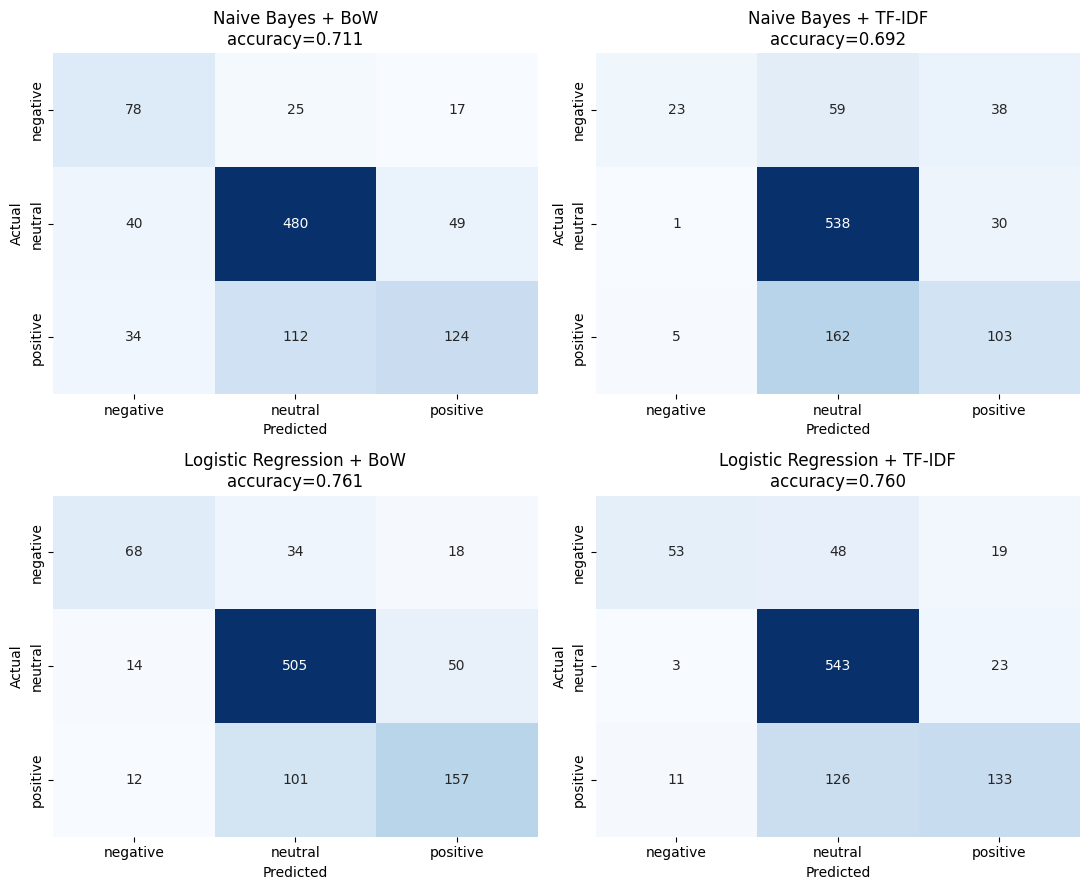

In [22]:
results = {
    "Naive Bayes + BoW": pred_nb_bow,
    "Naive Bayes + TF-IDF": pred_nb_tfidf,
    "Logistic Regression + BoW": pred_lr_bow,
    "Logistic Regression + TF-IDF": pred_lr_tfidf,
}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (title, y_pred) in zip(axes.ravel(), results.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax)
    ax.set_title(f"{title}\naccuracy={accuracy_score(y_test, y_pred):.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## Summary and takeaways

**Data quality fixes**
- **Leakage bug found and fixed**: an earlier version deduped only on the raw `(headline, sentiment)` pair (6 exact duplicates). Because different raw headlines can clean down to identical text, that missed rows whose *cleaned* text duplicated another row's, and some of those landed on opposite sides of the train/test split. Deduping on `clean_headline` instead fixes this; the leakage check above confirms zero shared text between splits.
- **Manual review of conflicting-label duplicates**: reading the *raw* text behind the 10 groups that shared cleaned text but disagreed on label (rather than guessing) showed 6 were a cleaning artifact -- the old cleaning discarded numbers and stripped "up"/"down" as stopwords, collapsing opposite-direction headlines into identical text. Fixing the cleaning resolved those to 5 genuine groups (real annotator disagreement or near-identical stylistic variants), which are dropped entirely rather than arbitrarily keeping one label.
- **Cleaning improvements**: numbers are bucketed by magnitude and sign (`smallnum`/`midnum`/`bignum`, `neg`-prefixed) instead of discarded, and direction/negation words ("up", "down", "not", etc.) are kept out of the stopword list. Final dataset: 4,795 rows (3,836 train / 959 test).

**Baselines after the cleaning fix**
- The cleaning fix alone lifted every baseline substantially: **Logistic Regression + BoW went from 73.7% to 76.1% accuracy** (macro-F1 0.667 -> 0.702), and **Logistic Regression + TF-IDF from 72.3% to 76.0%** (macro-F1 0.624 -> 0.670) -- a bigger jump than any single experiment below produced on its own.
- Logistic Regression still clearly beats Multinomial Naive Bayes on both feature types (76.1%/76.0% vs. 71.1%/69.2%), consistent with Naive Bayes' conditional-independence assumption being a poor fit for text where classes share most of their vocabulary.
- **SMOTE**: resampling Logistic Regression + TF-IDF's training split to 2,279 examples per class raises `negative` recall from 0.44 to 0.68 and `negative` F1 from 0.57 to 0.65, at a small accuracy cost (76.0% -> ~75%) and a macro-F1 gain over the TF-IDF baseline (0.670 -> 0.706). That said, it's the weakest of the four improvement experiments below by macro-F1 -- chi2, bigrams, and grid search all reach higher macro-F1 while also improving accuracy, which SMOTE trades away slightly.

**Follow-up experiments**

| Configuration | Accuracy | Macro-F1 |
|---|---|---|
| NB + BoW / TF-IDF (baseline) | 71.1% / 69.2% | 0.641 / 0.529 |
| LR + BoW / TF-IDF (baseline) | 76.1% / 76.0% | 0.702 / 0.670 |
| LR + TF-IDF + SMOTE | 75.5% | 0.706 |
| LR + BoW/TF-IDF + bigrams, mf=5000 | 77.2% / 75.7% | 0.717 / 0.662 |
| LR + BoW + chi2, k=2000 | **77.7%** | **0.723** |
| LR + BoW/TF-IDF, grid-searched | 77.3% / 77.3% | 0.718 / 0.716 |

- **Best single result: BoW + chi2 feature selection (k=2000), 77.69% accuracy, macro-F1 0.723** -- selecting tokens by how well they separate classes beat both adding more n-grams and grid-searching unsupervised vectorizer settings.
- Bigrams helped BoW but *hurt* TF-IDF; chi2 helped BoW a lot and TF-IDF barely (TF-IDF's own weighting already does something similar); GridSearchCV converged both feature extractors to a near-identical ~77.3%/0.72, closing most of the gap for TF-IDF specifically.

**How the exploratory analysis paid off**
- The finding that vocabulary/bigrams overlap heavily across classes directly motivated the chi2 feature selection above -- select for separation, not frequency -- which produced the single best result in the notebook.
- The finding that `negative`/`neutral` don't have the highest vocabulary overlap (contrary to the intuitive guess) redirected the "why does `negative` get confused" question toward sample size, which the SMOTE experiment addresses directly.
- Headline length was used only to set `max_features` intuitively; it was never used as a model feature in its own right, which is a concrete unused lead (see below).

**What's left to try**
- **Combine chi2 with GridSearchCV** -- the grid search above doesn't include chi2's `k`; searching `max_features`/`min_df`/`C`/chi2-`k` jointly (e.g. via a `Pipeline` with `SelectKBest` as a step) is the most direct next experiment, and the most likely to beat 77.69%.
- **`class_weight="balanced"` as an alternative (or complement) to SMOTE** -- reweights the loss function instead of resampling the data, cheaper to test and worth comparing against the SMOTE result.
- **Headline length as an explicit numeric feature** (via `FeatureUnion`/`ColumnTransformer` alongside the text features), since it was computed early on but never fed to a model.
- **A third algorithm** (linear SVM, or a small ensemble/voting classifier over NB + LR) to see whether a wider margin helps given how close together the classes' vocabularies sit.
- **Cross-validated reporting for the final chosen model**, not just a single train/test split -- changing the random seed already changed which baseline (BoW vs. TF-IDF) came out ahead, which is itself evidence that a single split is a noisy way to make a final call between close configurations.